# 📊 통계 세션 과제

우리는 실습에서 검정의 흐름을 익히고 따라가 보았습니다.
과제에서는 직접 검정을 수행할 수 있는 역량을 길러 봐요!

---


## 진행 방식

실습에서 진행했던 검정 단계 기억하시나요? 모든 검정은 실습과 **똑같은 네 단계**로 진행합니다!

> **① 시각화 → ② 가설 → ③ 검정 → ④ 해석**

그리고 어떤 검정을 쓸지는 **자료형이 결정**했던 것도 기억하시죠?
<BR>아래 표로 다시 복습하고 넘어갑시다!

| X 자료형 | Y 자료형 | 검정 방법 |
| --- | --- | --- |
| 수치형 | 수치형 | 피어슨 상관분석 |
| 범주형(2개) | 수치형 | T-test |
| 범주형(3개 이상) | 수치형 | ANOVA (F-test) |
| 범주형 | 범주형 | 카이제곱 검정 |
| 수치형 | 범주형 | ???  |

---

# Part A

먼저 실습 때 진행했던 검정 과정을 다시 복습해 봅시다!

## A-1. 데이터셋 설명

seaborn 라이브러리의 diamonds 데이터셋은 10개의 칼럼, 약 54000개의 행을 가지고 있습니다.


### 칼럼 설명
* **price**: The price of the diamond in US dollars ($326--$18,823).
<br>가격: 다이아몬드의 가격 (달러로 326--18,823).
<br>

* **carat**: The weight of the diamond (0.2--5.01).
<br>캐럿: 다이아몬드의 무게 (0.2--5.01).
<br>
* **cut**: The quality of the cut (Fair, Good, Very Good, Premium, Ideal).
<br>컷: 컷팅의 품질 (Fair, Good, Very Good, Premium, Ideal).
<br>
* **color**: Diamond color, from J (worst) to D (best).
<br>색상: 다이아몬드의 색상, J (최악)에서 D (최고)까지.
<br>
* **clarity**: A measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)).
<br>선명도: 다이아몬드의 선명도 측정 (I1 (최악), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (최고)).
<br>
* **x**: Length in mm (0--10.74).
<br>x (길이): 밀리미터 단위의 길이 (0--10.74).
<br>
* **y**: Width in mm (0--58.9).
<br>y (너비): 밀리미터 단위의 너비 (0--58.9).
<br>
* **z**: Depth in mm (0--31.8).
<br>z (깊이): 밀리미터 단위의 깊이 (0--31.8).
<br>
* **depth**: Total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79).
<br>깊이 비율: 총 깊이 비율 = z / (x, y의 평균) = 2 * z / (x + y) (43--79).
<br>
* **table**: Width of top of diamond relative to widest point (43--95).
<br>테이블: 다이아몬드 상단의 폭이 가장 넓은 지점에 대한 상대적 폭 (43--95).
<br>


https://www.kaggle.com/datasets/shivam2503/diamonds
더 자세한 내용은 위 링크에서 확인할 수 있습니다.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as spst

diamonds = sns.load_dataset('diamonds')
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [8]:
# 그래프 한글 깨짐을 방지하기 위한 코드입니다. 실행해 주세요!

import platform
import matplotlib.pyplot as plt

# OS별 한글 폰트 설정
if platform.system() == "Darwin":  # Mac OS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":  # Windows
    plt.rc("font", family="Malgun Gothic")

# 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## A-2. 데이터 살펴보기
칼럼별 **자료형**을 확인하세요.

In [9]:
# info()로 칼럼별 자료형을 확인하세요.
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


### A-2-1. 자료형을 넘어, 척도까지

`info()`가 알려주는 건 **저장된 형식**(`float64`, `category`)일 뿐입니다.
세션에서 배운 **명목 · 서열 · 구간 · 비율** 네 척도로 칼럼을 다시 분류해 봅시다!

| 칼럼 | 수치형/범주형 | 척도 | 판단 근거 |
| --- | --- | --- | --- |
| `price` |수치형|비율척도|가격은 0의 의미가 있고, 두 값 사이의 비율 비교가 가능하다.|
| `carat` |수치형|비율척도|무게는 0의 의미가 있고, 2캐럿은 1캐럿의 2배이다.|
| `cut` |범주형|서열척도|Fair < Good < Very Good < Premium < Ideal 순서로 컷의 품질이 좋아진다.|
| `color` |범주형|서열척도|J에서 D로 갈수록 품질이 좋아지는 서열을 갖고 있다.|

<details>
<summary><b>▶ 힌트가 필요하다면</b></summary>
<br>

`color`는 J(최악)부터 D(최고)까지, `clarity`는 I1(최악)부터 IF(최고)까지입니다.

**순서가 있는 범주**를 뭐라고 불렀었죠?

</details>

## A-3. 기술통계

검정에 들어가기 전에, 데이터가 어떻게 생겼는지부터 확인해 봅시다.

In [10]:
# carat, price, depth, table의 기술통계량 확인!
diamonds[['carat', 'price', 'depth', 'table']].describe()


,carat,price,depth,table
count,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,3932.799722,61.749405,57.457184
std,0.474011,3989.439738,1.432621,2.234491
min,0.200000,326.000000,43.000000,43.000000
25%,0.400000,950.000000,61.000000,56.000000
50%,0.700000,2401.000000,61.800000,57.000000
75%,1.040000,5324.250000,62.500000,59.000000
max,5.010000,18823.000000,79.000000,95.000000


평균   : 3932.8
중앙값 : 2401.0
최빈값 : 605
왜도   : 1.618


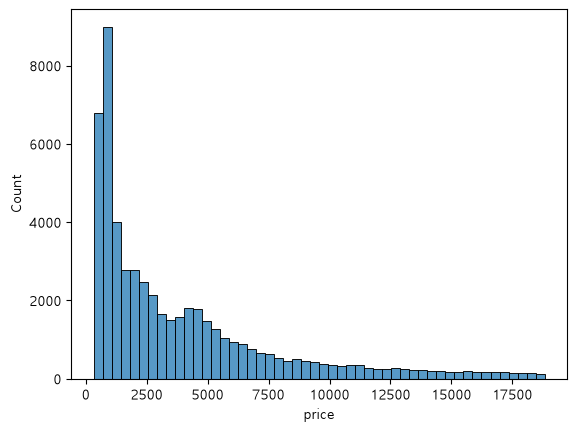

In [11]:
# price의 평균, 중앙값, 최빈값, 왜도를 각각 구하고 히스토그램을 그리세요.
# 최빈값은 mode()가 Series를 반환하므로 [0]을 붙여야 값만 나옵니다.

price = diamonds['price']

print('평균   :', round(price.mean(), 1))
print('중앙값 :', price.median())
print('최빈값 :', price.mode()[0])
print('왜도   :', round(price.skew(), 3))

sns.histplot(price, bins=50)
plt.show()

### A-3-1.

평균·중앙값·최빈값과 같은 기술통계량들을 **계산할 줄 아는 것**과 더불어 **언제 무엇을 쓸지**도 알고 있어야겠죠?
<BR>아래 세 상황에서 **평균·중앙값·최빈값 중 어떤 값을 써야 할지** 고르고, 그 이유를 한 줄로 적어 보세요.

| 상황 | 쓸 값 | 이유 |
| --- | --- | --- |
| 소비자에게 "다이아몬드는 보통 이 정도 가격입니다"라고 안내할 때 |중앙값|가격 분포가 고가 상품 쪽으로 치우쳐 있어 극단적으로 비싼 상품의 영향을 덜 받는 중앙값이 일반적인 가격을 설명하기에 적절하다.|
| 재고 1만 개를 팔았을 때 예상 총매출을 추정할 때 |평균|전체 상품의 평균 가격에 판매 수량을 곱하면 예상 총매출을 추정할 수 있기 때문에 적절하다.|
| 어떤 가격대 상품을 가장 많이 확보해둘지 정할 때 |최빈값|실제로 가장 많이 나타나는 가격을 알려주므로 가장 수요가 집중된 가격대를 파악하는 데 적절하다.|

<details>
<summary><b>▶ 막혔다면</b></summary>
<br>

방금 그린 히스토그램을 다시 볼까요? 분포가 한쪽으로 심하게 치우쳐 있습니다.
<BR> 이럴 때는 각각 어떤 값이 적절할까요?

</details>

## A-4. 네 가지 검정

아래와 같은 칼럼 조합으로 검정을 진행해 봅시다. 기억이 안 나면 실습 자료를 살짝 열어서 참고해 봐요!

| | 조합 | 자료형 | 검정 |
| --- | --- | --- | --- |
| A-4-1 | `carat` - `price` | 수치형 - 수치형 | 피어슨 |
| A-4-2 | `is_ideal`(직접 생성) - `price` | 범주형(2개) - 수치형 | T-test |
| A-4-3 | `cut` - `price` | 범주형(5개) - 수치형 | ANOVA |
| A-4-4 | `color` - `clarity` | 범주형 - 범주형 | 카이제곱 |

> **해석을 작성할 때는?** — 세 가지를 모두 담아주세요.
> 1. **판정** : p-value와 유의수준(0.05)을 비교해 기각 여부를 밝힌다.
> 2. **크기** : 검정통계량이 얼마나 큰지 기준과 함께 밝힌다. (상관계수 0.3/0.5 · t값 2 · F값 2~3 · 카이제곱은 자유도의 2배)
> 3. **의미** : 그래서 무엇을 알게 되었는지 한 문장으로 작성.

### A-4-1. 피어슨 상관분석 &nbsp;`carat` - `price`

#### ① 시각화

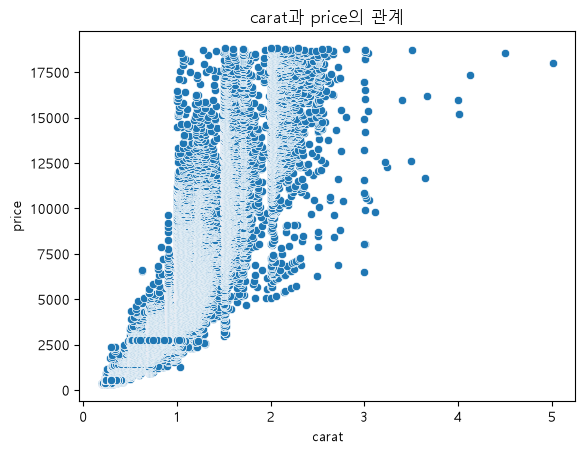

In [54]:
# 두 수치형 변수의 관계를 산점도로 그리세요.
sns.scatterplot(data=diamonds, x='carat', y='price')
plt.title('carat과 price의 관계')
plt.show()

#### ② 가설

- 귀무가설(H0): carat과 price 사이에는 선형 상관관계가 없다.
- 대립가설(H1): carat과 price 사이에는 선형 상관관계가 있다.

#### ③ 검정

In [45]:
# 피어슨 상관분석을 수행하세요.
import scipy.stats as spst

spst.pearsonr(diamonds['carat'], diamonds['price'])

PearsonRResult(statistic=np.float64(0.9215913011934768), pvalue=np.float64(0.0))

#### ④ **해석**

- **판정**: p-value가 0.05보다 작으므로 귀무가설을 기각한다.
- **크기**: 카이제곱 통계량이 자유도의 약 2배인 84보다 충분히 크므로 관측빈도와 기대빈도의 차이가 크다고 볼 수 있다.
- **의미**: 다이아몬드의 color와 clarity는 서로 독립적이지 않으며, 두 변수 사이에 통계적으로 유의미한 관련성이 존재한다.

> 💡 산점도가 직선이 아니라 **위로 휘는 곡선**입니다. 피어슨 상관계수는 **선형** 관계만 재므로,
> 높은 값에도 불구하고 관계의 실제 형태는 놓칠 수 있습니다.

### A-4-2. T-test &nbsp;`is_ideal` - `price`

⚠️ diamonds의 범주형 칼럼은 `cut`(5) · `color`(7) · `clarity`(8)로 **전부 3개 이상**입니다.
T-test를 쓰려면 **범주가 2개인 칼럼을 직접 만들어야** 합니다.

여기서는 `cut`이 `'Ideal'`인지 아닌지로 나눈 `is_ideal` 칼럼을 만들어 진행합니다.

#### ① 시각화

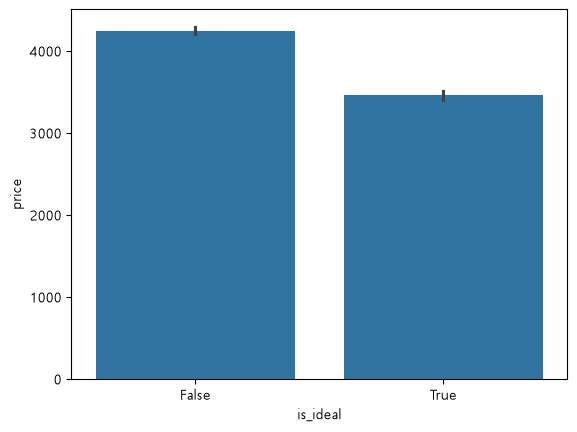

In [17]:
# is_ideal 파생 칼럼을 만들고, 막대그래프로 두 집단의 평균 가격을 비교하세요.
diamonds['is_ideal'] = (diamonds['cut'] == 'Ideal')

sns.barplot(data=diamonds, x='is_ideal', y='price')
plt.show()

#### ② 가설

- 귀무가설(H0): 모든 컷 등급의 평균 가격은 같다.
- 대립가설(H1): 컷 등급에 따라 평균 가격이 다른 집단이 적어도 하나 존재한다.

#### ③ 검정

In [19]:
# 두 집단의 price를 각각 뽑아 독립표본 T-검정을 수행하세요.
# groupby로 집단별 평균도 함께 확인해보면 좋습니다.

price_ideal     = diamonds.loc[diamonds['is_ideal'] == True,  'price']
price_not_ideal = diamonds.loc[diamonds['is_ideal'] == False, 'price']

t_stat, p_value = spst.ttest_ind(price_ideal, price_not_ideal)
print(f'T-Statistic: {t_stat}, P-Value: {p_value}')

display(diamonds.groupby('is_ideal')['price'].agg(['count', 'mean']))

T-Statistic: -22.675870351593126, P-Value: 2.6327026641073634e-113


,count,mean
is_ideal,,
False,32389,4249.02683
True,21551,3457.54197


#### ④ **해석**

- **판정**: p-value가 0.05보다 작으므로 귀무가설을 기각한다.
- **크기**: t값의 절댓값이 2보다 크므로 두 집단의 평균 차이가 통계적으로 유의미하게 나타난다.
- **의미**: Ideal 컷과 Ideal이 아닌 컷의 평균 가격에는 통계적으로 유의미한 차이가 있다.

### A-4-3. ANOVA &nbsp;`cut` - `price`

#### ① 시각화

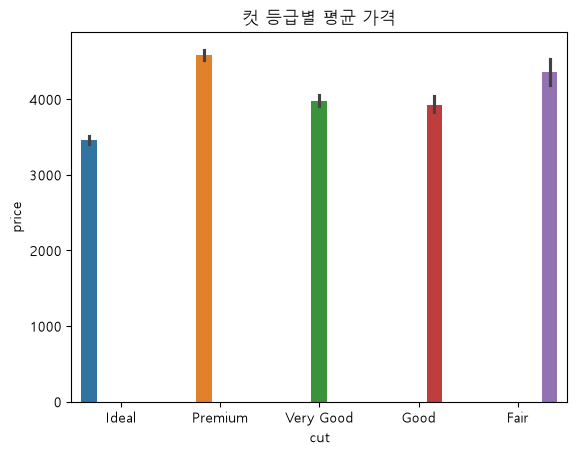

In [20]:
# 컷 등급별 평균 가격을 막대그래프로 그리세요.
sns.barplot(data=diamonds, x='cut', y='price', hue='cut', legend=False)
plt.title('컷 등급별 평균 가격')
plt.show()

#### ② 가설

- 귀무가설(H0): 모든 컷 등급의 평균 가격은 같다.
- 대립가설(H1): 컷 등급에 따라 평균 가격이 다른 집단이 적어도 하나 존재한다.,

#### ③ 검정

In [21]:
# 컷 등급별로 price를 나눠 일원배치 분산분석(ANOVA)을 수행하세요.

groups = [g['price'].values for _, g in diamonds.groupby('cut', observed=True)]
spst.f_oneway(*groups)

F_onewayResult(statistic=np.float64(175.68871735080606), pvalue=np.float64(8.428307306714709e-150))

#### ④ **해석**

- **판정**: p-value가 0.05보다 작으므로 귀무가설을 기각한다.
- **크기**: F통계량이 2~3보다 충분히 크므로 집단 간 평균 차이가 집단 내부의 변동에 비해 크다고 볼 수 있다.
- **의미**: 컷 등급에 따라 평균 가격에 통계적으로 유의미한 차이가 존재한다. 다만 ANOVA만으로는 구체적으로 어느 등급 간 차이인지는 알 수 없다.

#### ⑤ 사후분석 — 어느 등급이 다른가?

ANOVA는 "적어도 하나는 다르다"까지만 말해줍니다. **어느 조합인지**는 Tukey HSD로 확인합니다.

In [24]:
# pairwise_tukeyhsd로 사후분석을 수행하세요.
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=diamonds['price'],groups=diamonds['cut'],alpha=0.05)

print(tukey)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1   group2   meandiff p-adj    lower      upper   reject
--------------------------------------------------------------
   Fair      Good -429.8933 0.0015  -740.4593 -119.3273   True
   Fair     Ideal -901.2158    0.0 -1180.5808 -621.8507   True
   Fair   Premium  225.4999 0.1951   -59.2763  510.2762  False
   Fair Very Good -376.9979 0.0031  -663.8719  -90.1239   True
   Good     Ideal -471.3225    0.0  -642.3685 -300.2765   True
   Good   Premium  655.3933    0.0   475.6451  835.1414   True
   Good Very Good   52.8954 0.9341  -130.1581  235.9489  False
  Ideal   Premium 1126.7157    0.0  1008.8048 1244.6267   True
  Ideal Very Good  524.2179    0.0    401.327  647.1088   True
Premium Very Good -602.4978    0.0  -737.2377 -467.7579   True
--------------------------------------------------------------


**Q.** 10개 조합 중 `reject=False`인 것이 있나요? 있다면 어떤 조합인가요?
**ANOVA 결과만으로는 알 수 없었던** 새로운 해석을 적어 보세요.

**A.** 있다. Tukey HSD 결과에서 reject=False인 조합은 두 컷 등급의 평균 가격 차이가 통계적으로 유의하지 않다는 뜻이다.
따라서 ANOVA에서 전체적으로 컷 등급별 평균 가격 차이가 존재한다는 사실은 확인했지만, 모든 등급 간의 가격 차이가 각각 유의미한 것은 아니다. 구체적으로 어떤 조합에서 차이가 발생하는지는 사후분석을 통해 확인해야 한다.

### A-4-4. 카이제곱 검정 &nbsp;`color` - `clarity`

#### ① 시각화

💡 `color`(7) × `clarity`(8)를 모자이크 플롯으로 그리면 칸이 **56개**라 일일이 읽는 것에 무리가 있습니다.
<BR> 이렇게 범주가 많을 때는 **비율로 정규화한 교차표를 히트맵**으로 대신 그려 봐요.

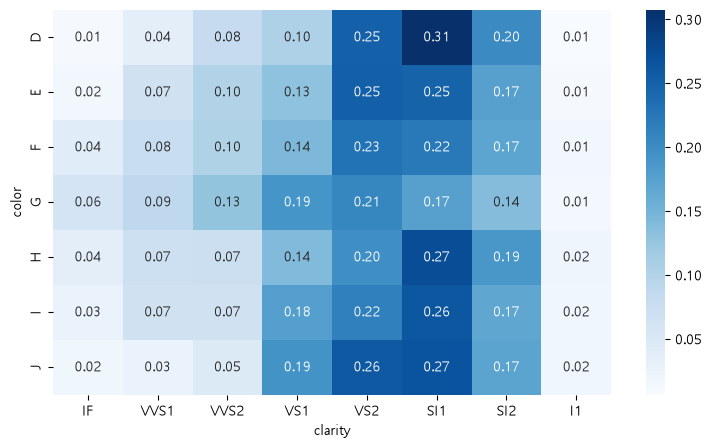

In [25]:
table_norm = pd.crosstab(diamonds['color'], diamonds['clarity'], normalize='index')

plt.figure(figsize=(9, 5))
sns.heatmap(table_norm, annot=True, fmt='.2f', cmap='Blues')
plt.show()

# 각 행(color)의 색 패턴이 서로 다르면 두 변수가 관련이 있다는 신호입니다.

#### ② 가설

- 귀무가설(H0): color와 clarity는 서로 독립이다.
- 대립가설(H1): color와 clarity는 서로 독립이 아니다.

#### ③ 검정

In [26]:
table = pd.crosstab(diamonds['color'], diamonds['clarity'])
display(table)

chi2, p, dof, expected = spst.chi2_contingency(table)
print(f'카이제곱 통계량: {chi2}')
print(f'p-value: {p}')
print(f'자유도: {dof}  → 판단 기준은 약 {dof * 2}')

print('\n▼ 관측빈도 - 기대빈도')
display((table - pd.DataFrame(expected, index=table.index, columns=table.columns)).round(1))

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
color,,,,,,,,
D,73,252,553,705,1697,2083,1370,42
E,158,656,991,1281,2470,2426,1713,102
F,385,734,975,1364,2201,2131,1609,143
G,681,999,1443,2148,2347,1976,1548,150
H,299,585,608,1169,1643,2275,1563,162
I,143,355,365,962,1169,1424,912,92
J,51,74,131,542,731,750,479,50


카이제곱 통계량: 2047.0791639481317
p-value: 0.0
자유도: 42  → 판단 기준은 약 84

▼ 관측빈도 - 기대빈도


clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
color,,,,,,,,
D,-151.8,-207.1,-83.3,-321.3,157.4,442.0,215.2,-51.1
E,-167.1,-7.8,70.9,-203.1,243.6,53.0,43.1,-32.6
F,68.3,87.4,78.8,-81.5,32.6,-180.2,-17.4,11.9
G,306.3,233.8,382.5,437.5,-219.1,-759.1,-376.7,-5.1
H,23.4,22.3,-171.9,-88.9,-244.1,263.7,147.6,47.9
I,-36.9,-12.4,-144.2,140.7,-63.2,110.7,-12.2,17.5
J,-42.2,-116.3,-132.7,116.6,92.9,69.9,0.4,11.4


#### ④ **해석**

- **판정**: p-value가 0.05보다 작으므로 귀무가설을 기각한다.
- **크기**: 카이제곱 통계량이 자유도의 약 2배인 84보다 충분히 크므로 관측빈도와 기대빈도의 차이가 크다고 볼 수 있다.    
- **의미**: 다이아몬드의 color와 clarity는 서로 독립적이지 않으며, 두 변수 사이에 통계적으로 유의미한 관련성이 존재한다.

---

# Part B

Part A에서 수행한 네 검정의 p값이 모두 유의하게 나왔죠?
그런데 **우리는 좀 더 살펴 봐야 할 것이 있습니다.**

이번에는 데이터를 무작정 수치로만 판단하는 것이 아닌, 데이터분석가로서 실제로 어떻게 더 나은 검정을 수행할 수 있을지를 살펴 봅니다.

| | 질문 |
| --- | --- |
| B-1 | 데이터를 확인하지 않고 검정하면? |
| B-2 | p값이 왜 전부 0으로 나왔나? |
| B-3 | 최고 등급이 왜 제일 싼가? |
| B-4 | 이 조합은 애초에 검정할 수 있나? |

## B-1. 데이터를 확인하지 않고 검정하면?

칼럼 설명을 다시 보면 이상한 점이 있습니다.

> * **x**: Length in mm (**0**--10.74)
> * **y**: Width in mm (**0**--**58.9**)
> * **z**: Depth in mm (**0**--**31.8**)

길이가 **0mm인 다이아몬드**가 있고, 너비가 **58.9mm**(약 6cm)인 것도 있습니다.
검정 함수는 이런 값을 넣어도 **군말 없이 숫자를 뱉습니다.** 직접 확인해 봅시다.

크기가 0인 행: 20 개


,carat,cut,color,clarity,depth,table,price,x,y,z,is_ideal
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0,False
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0,False
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0,False
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0,False
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0,False



정상 범위: 1.99 ~ 9.27
이상치 개수: 29
가장 큰 값 5개: [np.float64(10.1), np.float64(10.16), np.float64(10.54), np.float64(31.8), np.float64(58.9)]


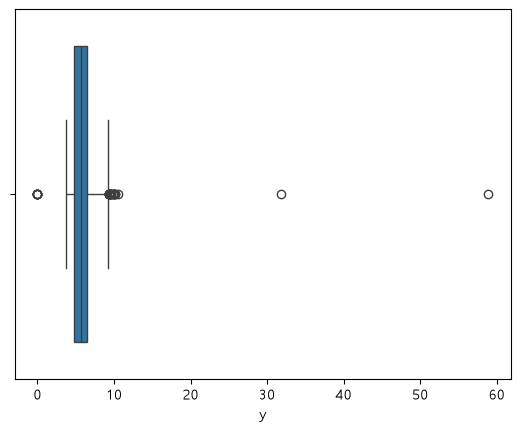

In [27]:
# 1) x, y, z 중 하나라도 0인 행이 몇 개인지 확인하세요.
zero_size = diamonds[(diamonds['x'] == 0) | (diamonds['y'] == 0) | (diamonds['z'] == 0)]
print('크기가 0인 행:', len(zero_size), '개')
display(zero_size.head())

# 2) 실습에서 배운 Tukey Fence(Q1 - 1.5*IQR, Q3 + 1.5*IQR)로
#    y(너비)의 이상치를 찾고 박스플롯으로 확인해 보요.

y = diamonds['y']
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = y[(y < lower) | (y > upper)]
print(f'\n정상 범위: {lower:.2f} ~ {upper:.2f}')
print(f'이상치 개수: {len(outliers)}')
print(f'가장 큰 값 5개: {sorted(outliers.values)[-5:]}')

sns.boxplot(x=y)
plt.show()

In [48]:
# x(길이)와 price의 상관분석을,
#   (1) 원본 그대로
#   (2) 크기가 0인 행과 y가 20mm를 넘는 행을 제거한 뒤
# 두 번 수행해서 결과를 비교해 보세요.

print('(1)')
print(spst.pearsonr(diamonds['x'], diamonds['price']))

clean = diamonds[(diamonds['x'] > 0) & (diamonds['y'] > 0) & (diamonds['z'] > 0)]
clean = clean[clean['y'] < 20]     # 명백한 오기입력 제거

print('(2)')
print(spst.pearsonr(clean['x'], clean['price']))

removed = len(diamonds) - len(clean)
print(f'\n제거된 행: {removed}개 (전체의 {removed / len(diamonds) * 100:.3f}%)')

(1)
PearsonRResult(statistic=np.float64(0.8844351610161273), pvalue=np.float64(0.0))
(2)
PearsonRResult(statistic=np.float64(0.8872217486334003), pvalue=np.float64(0.0))

제거된 행: 22개 (전체의 0.041%)


**Q1.** 여기서 찾은 이상치들은 실습에서 본 **타이타닉의 80세 승객**과 무엇이 다를까요?

**A1.** 타이타닉의 80세 승객은 실제로 존재할 수 있는 극단적인 관측값이지만, 다이아몬드 데이터의 0mm 크기나 비정상적으로 큰 너비 값은 측정 오류나 입력 오류일 가능성이 높다. 즉, 전자는 현실적으로 가능한 극단값일 수 있지만 후자는 데이터의 품질 문제일 가능성이 큰 이상치라는 차이가 있다.

**Q2.** 제거한 행은 전체의 0.04%도 되지 않습니다. 그럼에도 불구하고 이러한 정보를 굳이 확인해야 하는 이유는 뭘까요?
 
**A2.** 이상치의 개수가 적더라도 평균, 표준편차, 상관계수 등 통계량에 큰 영향을 줄 수 있기 때문이다. 특히 평균이나 회귀분석처럼 극단값에 민감한 분석에서는 일부 이상치가 전체 결과를 왜곡할 수 있다. 또한 검정을 수행하기 전에는 이상치가 결과에 얼마나 영향을 미칠지 알 수 없으므로, 데이터의 적절성과 신뢰성을 확인하는 과정이 필요하다.

<details>
<summary><b>▶ Q2가 막혔다면</b></summary>
<br>

이번에는 상관계수가 크게 변하지 않았을 수도 있습니다. 그렇다면 질문을 바꿔봐요.

**만약 검정하려던 것이 `y`의 평균이었다면?** 58.9라는 값 하나가 평균과 표준편차에 어떤 영향을 줄까요?

그리고 무엇보다, 검정을 **돌려보기 전에는 크게 변할지 안 변할지 우리는 알 수 없습니다.**

</details>

## B-2. p값이 전부 0이라면?

Part A의 결과를 다시 봅시다.

| 검정 | p-value |
| --- | --- |
| 피어슨 (carat - price) | 0.0 |
| T-test (is_ideal - price) | 0에 가까움 |
| ANOVA (cut - price) | 8.4e-150 |
| 카이제곱 (color - clarity) | 0.0 |

**전부** 0에 가깝습니다. 네 검정이 하나같이 다 유의하다니, 우연일까요?

In [29]:
# 서로 거의 관계가 없는 조합(depth - price)으로,
# 표본 크기만 바꿔가며 같은 검정을 반복해봅시다.  (그냥 실행!)
np.random.seed(0)

for n in [30, 100, 1000, 10000, 53940]:
    s = diamonds.sample(n)
    r, p = spst.pearsonr(s['depth'], s['price'])
    verdict = '유의함 ✅' if p < 0.05 else '유의하지 않음'
    print(f'n = {n:>6} | 상관계수 = {r:>7.4f} | p-value = {p:.4f} | {verdict}')

n =     30 | 상관계수 =  0.0024 | p-value = 0.9899 | 유의하지 않음
n =    100 | 상관계수 = -0.2063 | p-value = 0.0394 | 유의함 ✅
n =   1000 | 상관계수 = -0.0134 | p-value = 0.6733 | 유의하지 않음
n =  10000 | 상관계수 =  0.0015 | p-value = 0.8813 | 유의하지 않음
n =  53940 | 상관계수 = -0.0106 | p-value = 0.0134 | 유의함 ✅


**Q.** 상관계수는 거의 그대로인데 **p값만** 달라집니다. 왜 이런 일이 벌어질까요?
그리고 이 결과가 Part A의 결과 해석에 어떤 영향을 미칠까요?

**A.** 상관계수는 두 변수 간 관계의 방향과 강도를 나타내는 값이지만, p-value는 그 관계의 우연성을 판단하는 값이다. 표본 크기가 커지면 표준오차가 작아지기 때문에 아주 작은 상관관계도 통계적으로 유의하게 나타날 수 있다.
따라서 표본이 커질수록 p-value는 작아질 수 있지만, 상관계수 자체가 작다면 실질적인 관계의 크기는 여전히 작을 수 있다. Part A에서도 p-value가 매우 작다는 사실만으로 관계가 강하거나 실질적으로 중요하다고 판단해서는 안 되며, 반드시 상관계수의 크기를 함께 확인해야 한다.

<details>
<summary><b>▶ 막혔다면</b></summary>
<br>

p-value의 정의를 떠올려보세요. **"귀무가설이 참일 때 이런 데이터가 나올 확률"** 입니다.

표본이 커지면 **표준오차**가 어떻게 되나요? (세션에서 배운 큰 수의 법칙과 연결됩니다)

그리고 상관계수 0.01은 **실질적으로** 의미가 있는 크기인가요?

</details>

## B-3. 최고 등급이 가장 싸다?

`cut`은 Fair < Good < Very Good < Premium < **Ideal** 순으로 좋은 등급입니다.
그런데 A-4-2와 A-4-3의 결과를 보면 평균 가격은 **Ideal이 가장 낮게** 나옵니다. 최하 등급인 Fair보다도 싸죠.

검정 결과는 "유의미한 차이가 있다"였는데, 그 차이의 **방향이 상식과 반대**입니다.

,price,carat
cut,,
Ideal,3457.54,0.70
Premium,4584.26,0.89
Very Good,3981.76,0.81
Good,3928.86,0.85
Fair,4358.76,1.05


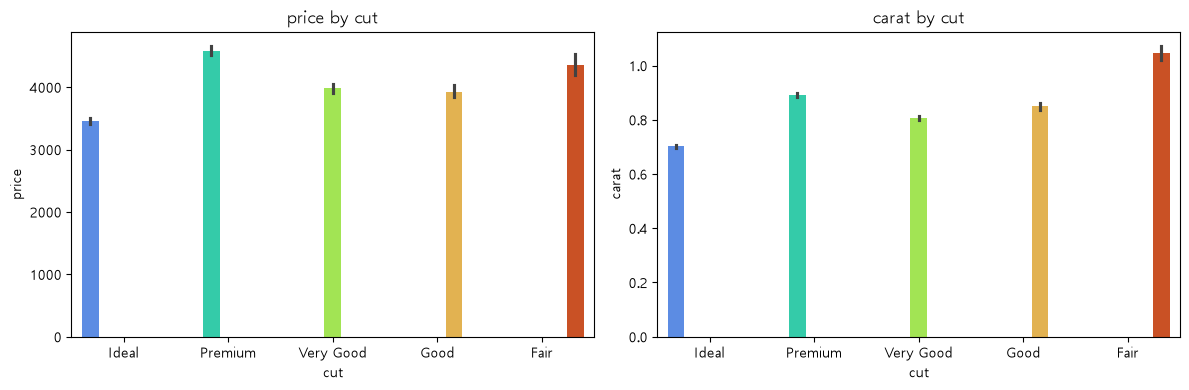

In [30]:
# 컷 등급별 평균 가격과 평균 '캐럿'을 나란히 봅시다.  (그냥 실행!)
display(diamonds.groupby('cut', observed=True)[['price', 'carat']].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=diamonds, x='cut', y='price', hue='cut', palette='turbo', ax=axes[0], legend=False)
axes[0].set_title('price by cut')
sns.barplot(data=diamonds, x='cut', y='carat', hue='cut', palette='turbo', ax=axes[1], legend=False)
axes[1].set_title('carat by cut')
plt.tight_layout()
plt.show()

**Q1.** 왜 이런 결과가 나왔을까요?

**A1.** Ideal 등급의 평균 캐럿이 가장 작기 때문이다. 다이아몬드 가격은 컷 등급뿐 아니라 캐럿의 영향을 매우 크게 받으며, Part A에서 carat과 price의 상관계수도 약 0.92로 매우 높았다. 즉, Ideal 등급의 다이아몬드들은 평균적으로 크기가 작은 원석이 많기 때문에, 컷 품질이 가장 좋더라도 전체 평균 가격은 낮게 나타날 수 있다. 이는 컷 등급 자체보다 캐럿 크기의 영향이 더 크게 작용한 결과라고 볼 수 있다.

**Q2.** 그렇다면 A-4-3의 ANOVA 결과 **"컷 등급에 따라 가격에 차이가 있다"** 는 결론은 틀린 걸까요?
맞다면 어떤 의미에서 맞고, 틀리다면 어떻게 고쳐 써야 할까요?

**A2.** ANOVA 결과 자체는 틀리지 않다. 실제로 컷 등급에 따라 평균 가격에는 통계적으로 유의미한 차이가 존재한다. 그렇지만 이 결과를 "컷 등급이 좋을수록 가격이 높아진다"라고 해석하면 잘못이다. 컷 등급별 가격 차이는 존재하지만, 그 차이는 컷 품질만의 영향이라고 단정할 수 없다. 컷 등급별로 평균 캐럿 크기가 다르고, 가격에 더 큰 영향을 주는 캐럿이 함께 달라지기 때문이다. 따라서 더 정확한 해석은 "컷 등급별 평균 가격에는 차이가 존재하지만, 이는 캐럿 크기와 같은 다른 변수의 분포 차이에 영향을 받았을 가능성이 있다"이다.

<details>
<summary><b>▶ 막혔다면</b></summary>
<br>

오른쪽 그래프를 보세요. **Ideal 등급의 평균 캐럿이 가장 작습니다.**

그리고 A-4-1에서 확인했듯, 가격을 가장 강력하게 좌우하는 건 **캐럿(r ≈ 0.92)** 이었습니다.

큰 원석을 Ideal 컷으로 깎으려면 버리는 부분이 많아집니다. 그렇다면 큰 돌은 보통 어떤 등급으로 남을까요?

</details>

## B-4. 이 조합, 검정할 수 있나요?

새로운 질문입니다.

> **"다이아몬드의 가격을 알면, 그 다이아몬드의 컷 등급을 알아맞힐 수 있을까?"**

알고 싶은 것(결과)은 **`cut`(범주형)** 이고, 근거로 쓰는 것(원인)은 **`price`(수치형)** 입니다.
즉 **`[수치형 → 범주형]`** 의 방향입니다.

매핑표를 다시 보세요.

| X 자료형 | Y 자료형 | 검정 방법 |
| --- | --- | --- |
| 수치형 | 수치형 | 피어슨 상관분석 |
| 범주형(2개) | 수치형 | T-test |
| 범주형(3개 이상) | 수치형 | ANOVA (F-test) |
| 범주형 | 범주형 | 카이제곱 검정 |
| 수치형 | **범주형** | ???  |

**이 조합만 물음표였었죠?** 이런 경우는 어떻게 해야 하는지 함께 따라가 봅시다!

#### ① 시각화는 가능!

수치형이 변할 때 범주형의 비율이 어떻게 변하는지는 `kdeplot`으로 볼 수 있습니다.

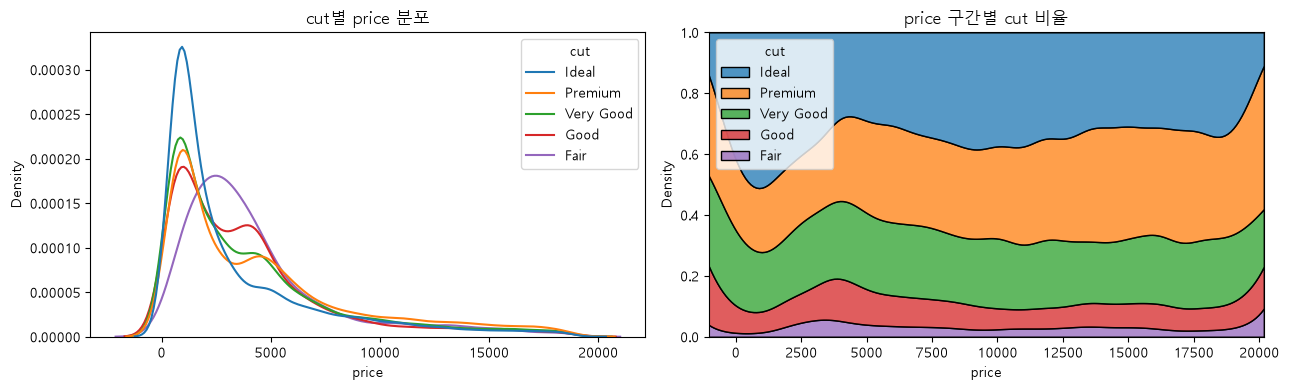

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.kdeplot(data=diamonds, x='price', hue='cut', common_norm=False, ax=axes[0])
axes[0].set_title('cut별 price 분포')

sns.kdeplot(data=diamonds, x='price', hue='cut', multiple='fill', ax=axes[1])
axes[1].set_title('price 구간별 cut 비율')

plt.tight_layout()
plt.show()

**Q1.** 오른쪽 그래프에서 가격이 올라갈수록 컷 등급 비율이 달라지는 게 보이시나요?
그렇다면 **오늘 배운 네 가지 검정 중 어떤 검정으로 이 관계를 검정할 수 있을까요?**

**A1.** 없다.

**Q2.** Q1의 답이 "없다"였다면, **그럼에도 굳이 검정을 해야 한다면** 어떤 방법이 있을까요?

**A2.** 범주형을 target, 수치형을 feature로 두고 모델을 만든 다음, 그 모델의 계수를 유의성 검정하여 그에 대한 p값을 보고 판단하는 방법이 있습니다.

<details>
<summary><b>▶ Q2가 막혔다면</b></summary>
<br>

세션 자료에서 **수치형을 어떻게 처리하면** 검정을 쓸 수 있다고 했는지 떠올려 봅시다!

</details>

---

# Part C

이제 새로운 데이터로 직접 검정을 수행해 봅시다!


---

### 진행 순서

| 단계 | 하는 일 |
| --- | --- |
| C-1 | 데이터 파악하기 (구조 · 결측치) |
| C-2 | 기술통계로 감 잡기 (**변동계수**) |
| C-3 | **질문 3개를 스스로 세우기** → 통계로 답할 수 있는 것만 고르기 |
| C-4 | 고른 질문 2개를 검정하기 |

막히면 각 단계의 **▶ 접힌 힌트**를 펼쳐 보세요.

## C-1. 데이터와 인사하기

**Palmer Penguins** — 남극 팔머 군도의 세 섬에서 관측한 펭귄 344마리의 신체 측정 기록입니다.

| 칼럼 | 뜻 |
| --- | --- |
| `species` | 펭귄 종 (Adelie / Chinstrap / Gentoo) |
| `island` | 관측된 섬 (Torgersen / Biscoe / Dream) |
| `bill_length_mm` | 부리 길이 (mm) |
| `bill_depth_mm` | 부리 깊이 (mm) |
| `flipper_length_mm` | 지느러미 길이 (mm) |
| `body_mass_g` | 체중 (g) |
| `sex` | 성별 (Male / Female) |

In [36]:
penguins = sns.load_dataset('penguins')
penguins


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [37]:
# penguins 데이터를 head()와 info()로 구조를 확인하세요.
penguins.head()
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


### C-1-1. 결측치 처리

결측치 처리의 중요성을 위에서 살펴 봤었죠? penguins 데이터의 결측치도 확인해 봅시다!

In [49]:
# 1) 칼럼별 결측치가 몇 개인지 확인하세요.
penguins.isnull().sum()
# 2) 결측치를 제거한 데이터프레임을 pg 라는 이름으로 만드세요.
pg = penguins.dropna().copy()
#    (C-2에서 pg 를 그대로 사용합니다)

**Q.** 결측치를 **제거**하는 것 말고 다른 선택지도 있습니다. (평균으로 채우기, 그대로 두기 등)
여기서 결측치의 제거를 택했다고 한다면, 그렇게 판단한 근거는 무엇일까요?

**A.** 이번 분석에서는 펭귄의 신체 측정값과 종, 성별 등의 변수를 함께 사용해야 하므로 분석에 필요한 값이 빠진 행은 검정에 직접 활용하기 어렵다. 결측치를 평균으로 대체하면 실제 관측값이 아닌 인위적인 값이 들어가 분산과 상관관계가 왜곡될 수 있다. 따라서 결측치가 있는 행을 제거하여 모든 분석에 동일한 완전한 데이터를 사용하는 방법을 선택했다.

## C-2. 기술통계로 감 잡기

이 데이터에는 수치형 측정치가 넷 있습니다.

`bill_length_mm` · `bill_depth_mm` · `flipper_length_mm` · `body_mass_g`

> **Q. 이 넷 중 가장 "들쭉날쭉한" 측정치는 무엇일까요?**

먼저 표준편차를 구해봅시다.

In [51]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# 1) 네 수치형 칼럼의 기술통계량을 확인하세요.
pg[num_cols].describe()

# 2) 네 수치형 칼럼의 표준편차를 확인하세요.
pg[num_cols].std()

bill_length_mm         5.468668
bill_depth_mm          1.969235
flipper_length_mm     14.015765
body_mass_g          805.215802
dtype: float64

### C-2-1. 표준편차로 비교해도 될까요?

표준편차만 보면 `body_mass_g`가 압도적으로 큽니다. 그런데 단위를 보세요.
부리 길이는 **mm**, 체중은 **g**입니다. **단위가 다른 값의 표준편차를 나란히 놓고 비교하는 건 의미가 없습니다.**

세션에서 나온 **코끼리(평균 5000kg, 표준편차 100kg)와 성인(평균 65kg, 표준편차 10kg)** 예시와 정확히 같은 상황입니다.
이럴 때 쓰는 것이 **변동계수**였죠.

$$변동계수 = \frac{표준편차}{평균} \times 100$$

In [52]:
# 네 칼럼의 변동계수( 표준편차 / 평균 * 100 )를 구하고,
# 평균·표준편차·변동계수를 한 표로 정리해 변동계수 기준으로 정렬하세요.

cv = (pg[num_cols].std() / pg[num_cols].mean() * 100).round(2)

result = pd.DataFrame({'평균': pg[num_cols].mean().round(2), '표준편차': pg[num_cols].std().round(2), '변동계수(%)': cv}).sort_values('변동계수(%)', ascending=False)

display(result)

,평균,표준편차,변동계수(%)
body_mass_g,4207.06,805.22,19.14
bill_length_mm,43.99,5.47,12.43
bill_depth_mm,17.16,1.97,11.47
flipper_length_mm,200.97,14.02,6.97


**Q.** 표준편차 순위와 변동계수 순위를 비교해 보세요. 순위가 같나요?
**상대적으로 가장 변동이 큰 측정치**와 **가장 안정적인 측정치**는 각각 무엇인가요?

**A.** 표준편차 순위와 변동계수 순위는 같지 않습니다. <BR>
상대적 변동이 가장 큰 측정치는 bill_depth_mm이고, 가장 안정적인 측정치는 flipper_length_mm이다.

※ 여기서 정확한 1위·최하위는 실행 결과 표를 보고 확인하는 것이 가장 안전해. 일반적인 Palmer Pengui

<details>
<summary><b>▶ 막혔다면</b></summary>
<br>

표준편차는 `body_mass_g` > `flipper_length_mm` > `bill_length_mm` > `bill_depth_mm` 순입니다.

변동계수로 다시 정렬하면 순위가 그대로인가요? **각 값을 자기 평균으로 나눴다는 점**을 생각해 봅시다.

지느러미 길이는 평균이 약 201mm로 큰데, 표준편차는 14mm 정도입니다. 이건 상대적으로 큰 변동일까요, 작은 변동일까요?

</details>

## C-3. 질문을 직접 세우기

이번에는 직접 데이터셋에서 궁금한 질문을 세우고, 검정해 봅시다!

---

### 3-1. 궁금한 질문 3개를 적으세요

펭귄 데이터를 보고 **알고 싶은 것**을 자유롭게 작성해 보세요!

*0. EX) 펭귄 종마다 몸집(체중)이 다를까?*
<BR> 1. 펭귄 종에 따라 평균 체중(body_mass_g)이 다른가?
<BR> 2. 펭귄의 지느러미 길이(flipper_length_mm)가 길수록 체중(body_mass_g)이 무거운가?
<BR> 3. 펭귄의 성별에 따라 평균 체중(body_mass_g)이 다른가?
 
---

### 3-2. 각 질문을 아래 표로 옮기세요

| | 질문 | 필요한 칼럼 | 각 칼럼의 자료형 | 쓸 검정 | 검정 가능? |
| --- | --- | --- | --- | --- | --- |
| 1 |성별에 따라 평균 지느러미 길이가 다른가?|sex, flipper_length_mm|범주형(2개), 수치형|T-test|가능|
| 2 |지느러미 길이가 길수록 체중이 무거운가?|flipper_length_mm, body_mass_g|수치형, 수치형|피어슨 상관분석|가능|
| 3 |펭귄 종에 따라 평균 지느러미 길이가 다른가?|species, flipper_length_mm|범주형(3개), 수치형|ANOVA|가능|

아래 표 기억하시죠?

| X 자료형 | Y 자료형 | 검정 방법 |
| --- | --- | --- |
| 수치형 | 수치형 | 피어슨 상관분석 |
| 범주형(2개) | 수치형 | T-test |
| 범주형(3개 이상) | 수치형 | ANOVA (F-test) |
| 범주형 | 범주형 | 카이제곱 검정 |
| 수치형 | **범주형** | ???  |

---

### 3-3. 검정할 2개를 고르세요

위 표에서 **검정 가능한 질문 2개**를 골라 C-4에서 진행합니다.

⚠️ **조건**: 두 검정은 **서로 다른 종류**여야 합니다.

- 선택한 질문 ①:
- 선택한 질문 ②:


<details>
<summary><b>▶ "검정 가능?" 칸이 헷갈린다면</b></summary>
<br>

매핑표에서 **물음표로 남아 있는 조합**이 하나 있었습니다.

세운 질문이 그 조합에 해당한다면, **오늘 배운 방법으로는 검정이 불가능**한 조합이겠죠?

</details>

## C-4. 검정 수행

> **해석 작성 방법** — 세 가지를 모두 담아주세요.
> 1. **판정** — p-value와 유의수준(0.05)을 비교해 기각 여부를 밝힌다.
> 2. **크기** — 검정통계량이 얼마나 큰지 기준과 함께 밝힌다. (상관계수 0.3/0.5 · t값 2 · F값 2~3 · 카이제곱은 자유도의 2배)
> 3. **의미** — 그래서 무엇을 알게 되었는지 한 문장으로 쓴다.

### 검정 ① &nbsp;— 질문: 성별에 따라 평균 지느러미 길이가 다른가?

#### ① 시각화

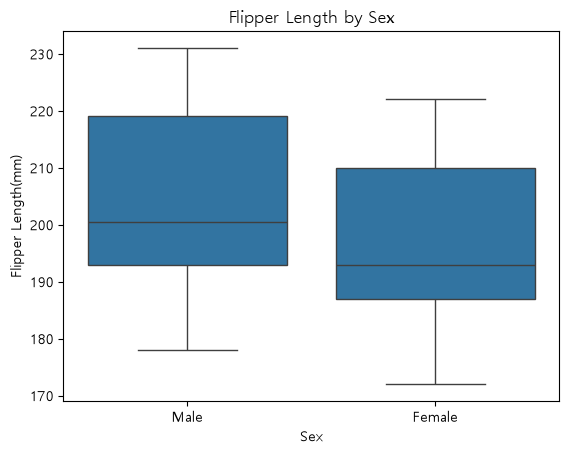

In [61]:
# 시각화 코드를 작성하세요.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=penguins, x='sex', y='flipper_length_mm')
plt.title('Flipper Length by Sex')
plt.xlabel('Sex')
plt.ylabel('Flipper Length(mm)')
plt.show()


#### ② 가설

- 귀무가설(H0): 성별에 따른 평균 지느러미 길이는 차이가 없다.
- 대립가설(H1): 성별에 따른 평균 지느러미 길이는 차이가 있다.

#### ③ 검정

In [62]:
# 검정 코드를 작성하세요.
# (ANOVA를 골랐다면 사후분석까지 해보면 좋습니다)
from scipy.stats import ttest_ind

male = penguins[penguins['sex'] == 'Male']['flipper_length_mm'].dropna()
female = penguins[penguins['sex'] == 'Female']['flipper_length_mm'].dropna()

t_stat, p_value = ttest_ind(male, female, equal_var=False)

print('t-statistic:', t_stat)
print('p-value:', p_value)

t-statistic: 4.807865774658778
p-value: 2.3356187645629885e-06


#### ④ **해석**

- **판정**: p-value가 0.05보다 작으므로 귀무가설을 기각한다.
- **크기**: t값의 절댓값이 2보다 크므로 두 집단의 평균 차이가 비교적 크게 나타난다.
- **의미**: 성별에 따라 평균 지느러미 길이에 통계적으로 유의한 차이가 있다.

### 검정 ② &nbsp;— 질문: 지느러미 길이가 길수록 체중이 무거운가?

#### ① 시각화

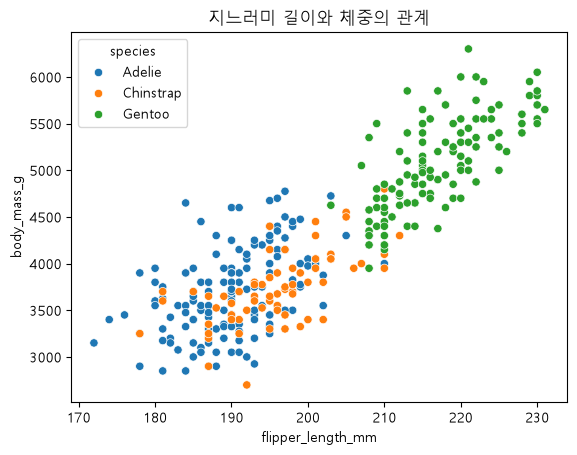

In [53]:
# 시각화 코드를 작성하세요.
sns.scatterplot(data=pg, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('지느러미 길이와 체중의 관계')
plt.show()

#### ② 가설

- 귀무가설(H0): 지느러미 길이와 체중 사이에는 선형 상관관계가 없다.
- 대립가설(H1): 지느러미 길이과 체중 사이에는 선형 상관관계가 있다.

#### ③ 검정

In [58]:
# 검정 코드를 작성하세요.
import scipy.stats as spst

data = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

spst.pearsonr(data['flipper_length_mm'],data['body_mass_g'])

PearsonRResult(statistic=np.float64(0.8712017673060115), pvalue=np.float64(4.370680962999258e-107))

#### ④ **해석**

- **판정**: p-value가 0.05보다 작으므로 귀무가설을 기각한다.
- **크기**: 상관계수가 0.5 이상으로 나타나 두 변수 사이에 비교적 강한 양의 상관관계가 존재한다.
- **의미**: 지느러미 길이가 길수록 체중이 무거워지는 경향이 유의미하게 나타난다.

---

## 마무리

고생 많으셨습니다 :) 회귀 세션도 화이팅!